
# VLA-style layer-locked readout: can it recover EI and the realized reward increment?

**Question this probes:** `docs/ROADMAP.md` §3.2 currently reads all `L` layers of the frozen
PFN by concatenating every layer's train-token hidden states into one flat `L·t`-token sequence,
then running a single shallow cross-attention block over the concatenation. An alternative,
closer to how VLA action experts (π0.5, cited in `docs/PROBLEM_SETTING.md`) read a frozen
backbone: a same-depth, smaller-width expert that cross-attends into ONE layer's hidden states
per expert layer, sequentially — giving the readout itself genuine depth (nonlinear processing
*between* layer-reads) instead of one flat attention pool, at the same total cross-attention FLOP
count (both designs do `n_query · L · t` key comparisons in total; this one just structures them
sequentially instead of as one `L·t`-wide softmax).

This notebook builds that alternative (`models/layer_locked_readout.py`'s `LayerLockedReadout`)
and trains it against **two** targets, side by side, on the SAME inputs:

- **Arm A — closed-form EI.** Known exactly from the frozen model's own bar distribution at the
  query (`model.bar_dist.ei`) — a clean, low-variance, analytic target. This is the sanity-check
  arm: if the readout can't recover this, nothing downstream is worth trying.
- **Arm B — the realized one-step reward increment.** This is what `docs/ROADMAP.md` §4.1's Phase
  1 (supervised myopic pretraining) actually regresses on — "realized `g_{t+1}`, not distilled
  LogEI" — computed by actually evaluating the true underlying function at each candidate (one
  noisy Monte Carlo draw, exactly like a real rollout would realize) and reading off the reward
  increment through the tail-quantile machinery (`reward/tail_quantile_reward.py`,
  `priors/quantile_table.py`). Much noisier than Arm A by construction (mostly exact zero, a
  single noisy draw rather than an expectation) — this is the actually-relevant difficulty Phase 1
  training would face, not a proxy for it.

Both arms cross-attend into ONLY the frozen PFN's train-token hidden states (never its own
query-conditioned output) — the same information budget a real future policy would have.

**Incumbent anchor token.** EI, PI, UCB — and the reward increment itself — are all functionals
evaluated *at* the incumbent `y*_t` specifically. Rather than making the expert rediscover which
of the `t` train tokens is the incumbent from context alone, a small per-layer learned embedding
of `y*_t` is concatenated as an extra key/value pair into that layer's cross-attention KV set —
additive, expert-side only, never touches the frozen PFN's own forward pass. Mirrors §3.3's own
incumbent-relative philosophy (resampling the candidate descriptor's bin grid so `y*_t` sits at a
fixed index) on the input/readout side instead of the output/descriptor side.

**Prediction head: binned (bar-distribution), not MSE, for both arms.** Both EI and the realized
reward increment are heavily right-skewed and mostly near-zero — exactly the kind of target this
project already treats with a log-scale binned representation rather than raw regression (see the
tail-quantile reward's own rationale for avoiding exactly this failure mode). The target for each
arm is `z = clip(log10(score + eps), Z_LO, Z_HI)`, binned uniformly in `z`-space (equivalent to
log-spaced bins in raw score-space), trained with the same NLL `BarDistribution.forward` already
uses for the PFN's own `y`-output — reused directly rather than inventing a second convention.

**Model:** the bidirectional checkpoint (`models/pfn_variable_xdim_smoke.pt`), per the
2026-09-08 decision to stick with bidirectional for now
(`docs/logs/2026-09-08-causal-vs-bidirectional-pfn-comparison.md`). Frozen throughout — only the
two expert readouts' own parameters are trained.

**A cost note on Arm B, stated plainly:** the realized reward needs a per-instance reward
reference (`QuantileTable`), which is expensive to build (it needs many real forward passes
through the true function). Rebuilding it every training step (fresh instances every step) would
make this notebook impractically slow, so instances are only re-drawn (and the reward reference
rebuilt) every `RESET_EVERY` steps; in between, fresh train/query *points* are still drawn every
step from the *same* underlying function batch via `sample_episode` (no `reset()`). This trades
some instance diversity for tractable runtime — a deliberate, documented compromise, not a claim
that step-to-step instance diversity doesn't matter.


In [1]:

import time

import matplotlib.pyplot as plt
import torch
from scipy.stats import spearmanr

from anytimeacquisition.models.bar_distribution import BarDistribution, uniform_bin_borders
from anytimeacquisition.models.layer_locked_readout import LayerLockedReadout
from anytimeacquisition.pipelines.train_pfn import load_pfn_checkpoint
from anytimeacquisition.priors.bnn import BNNPrior
from anytimeacquisition.priors.quantile_table import QuantileTable
from anytimeacquisition.reward.tail_quantile_reward import g_reward_minimize_from_table

torch.manual_seed(0)
device = "cpu"

CHECKPOINT_PATH = "../models/pfn_variable_xdim_smoke.pt"
model, bar_dist, ckpt = load_pfn_checkpoint(CHECKPOINT_PATH, device=device)
model.eval()
for p in model.parameters():
    p.requires_grad_(False)
print("frozen PFN config:", ckpt["config"])

X_DIM = ckpt["config"]["max_x_dim"]
D_MODEL_PFN = ckpt["config"]["d_model"]
N_LAYERS = ckpt["config"]["n_layers"]


/home/ruhkopf/PycharmProjects/AnytimeAcquisition/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


frozen PFN config: {'max_x_dim': 6, 'd_model': 64, 'n_heads': 4, 'n_layers': 4, 'd_ff': 128, 'n_bins': 64}


In [2]:

# Expert architecture -- deliberately small relative to the frozen PFN
# (d_expert << d_model_pfn), matching the "VLA action expert is cheap
# relative to the backbone" pattern this design is modeled on. Two
# independent readout instances, one per arm, trained jointly on the same
# inputs each step (a single frozen forward is reused for both).
D_EXPERT, N_HEADS_EXPERT, D_FF_EXPERT = 32, 4, 64
N_BINS, Z_LO, Z_HI, EPS = 64, -6.0, 0.0, 1e-8

readout_ei = LayerLockedReadout(D_MODEL_PFN, D_EXPERT, N_HEADS_EXPERT, N_LAYERS, D_FF_EXPERT, X_DIM, N_BINS).to(device)
readout_dg = LayerLockedReadout(D_MODEL_PFN, D_EXPERT, N_HEADS_EXPERT, N_LAYERS, D_FF_EXPERT, X_DIM, N_BINS).to(device)
bar_dist_score = BarDistribution(uniform_bin_borders(N_BINS, lo=Z_LO, hi=Z_HI)).to(device)
opt = torch.optim.Adam(list(readout_ei.parameters()) + list(readout_dg.parameters()), lr=1e-3)

n_params_per_arm = sum(p.numel() for p in readout_ei.parameters())
n_params_frozen = sum(p.numel() for p in model.parameters())
print(f"expert params (per arm): {n_params_per_arm:,}  (frozen PFN: {n_params_frozen:,}, "
      f"ratio {n_params_per_arm / n_params_frozen:.2%})")


expert params (per arm): 45,280  (frozen PFN: 139,200, ratio 32.53%)


In [3]:

# Same prior family the checkpoint was trained on (x_dim=6, variable_dim_min=1
# -- see the checkpoint's own training log, docs/logs/2026-09-08-causal-vs-bidirectional-pfn-comparison.md).
BATCH_SIZE, N_QUERY = 32, 32
N_TRAIN_RANGE = (3, 20)
RESET_EVERY = 50
QT_KWARGS = dict(n_samples=10_000, n_grid=512, n_exact_tail=128, chunk_size=5_000)

train_prior = BNNPrior(batch_size=BATCH_SIZE, x_dim=X_DIM, variable_dim_min=1, device=device, seed=1)


def sample_points(prior, n_train_range=N_TRAIN_RANGE, n_query=N_QUERY, generator=None):
    n_train = torch.randint(n_train_range[0], n_train_range[1] + 1, (1,), generator=generator).item()
    return prior.sample_episode(n_train=n_train, n_test=n_query)  # x_train, y_train, x_query, _


def compute_targets(prior, qt, x_train, y_train, x_query):
    '''Ground truth for both arms, plus the train-only per-layer hidden
    states the readouts are allowed to see. Everything here runs under
    no_grad -- the frozen PFN AND the ground-truth reward machinery are
    both privileged/non-differentiable supervision, not part of the
    trained graph.'''
    with torch.no_grad():
        logits_frozen, hidden_states = model(x_train, y_train, x_query, return_hidden=True)
        y_incumbent = y_train.min(dim=1).values
        n_train = x_train.shape[1]
        train_hidden = [h[:, :n_train] for h in hidden_states]

        # Arm A: closed-form EI from the frozen model's own belief.
        ei_true = model.bar_dist.ei(logits_frozen, best_f=y_incumbent)  # [B, n_query]
        z_ei = torch.log10(ei_true.clamp_min(EPS)).clamp(Z_LO, Z_HI)

        # Arm B: realized one-step reward increment -- actually evaluate the
        # TRUE function (one noisy draw, like a real rollout would realize),
        # then read the reward increment through the tail-quantile machinery.
        y_actual = prior.evaluate(x_query, noise=True)  # [B, n_query]
        new_incumbent = torch.minimum(y_incumbent.unsqueeze(1), y_actual)
        g_before = g_reward_minimize_from_table(qt, y_incumbent)  # [B]
        g_after = g_reward_minimize_from_table(qt, new_incumbent)  # [B, n_query]
        delta_g = (g_after - g_before.unsqueeze(1)).clamp_min(0)
        z_dg = torch.log10(delta_g.clamp_min(EPS)).clamp(Z_LO, Z_HI)

    return train_hidden, y_incumbent, ei_true, z_ei, delta_g, z_dg


# Fixed held-out probe set (instances AND points, not resampled during
# training) -- a low-noise validation signal, same rationale as
# callbacks/dim_validation.py's dedicated validation priors. Arm B's
# realized delta_g is itself a single noisy draw even at eval time, matching
# what the readout is actually being asked to predict -- deliberately not
# Monte-Carlo-averaged into a cleaner target, so this stays an honest read
# of Arm B's actual achievable ceiling, not an easier proxy for it.
val_gen = torch.Generator(device=device).manual_seed(123)
val_prior = BNNPrior(batch_size=BATCH_SIZE, x_dim=X_DIM, variable_dim_min=1, device=device, seed=999)
val_prior.reset()
val_qt = QuantileTable(val_prior, **QT_KWARGS)
VAL_POINTS = [sample_points(val_prior, generator=val_gen) for _ in range(5)]


In [4]:

def evaluate():
    losses_ei, losses_dg = [], []
    all_ei_true, all_ei_pred, all_dg_true, all_dg_pred = [], [], [], []
    with torch.no_grad():
        for x_train, y_train, x_query, _ in VAL_POINTS:
            train_hidden, y_incumbent, ei_true, z_ei, delta_g, z_dg = compute_targets(
                val_prior, val_qt, x_train, y_train, x_query
            )
            logits_ei = readout_ei(x_query, train_hidden, y_incumbent)
            logits_dg = readout_dg(x_query, train_hidden, y_incumbent)
            losses_ei.append(bar_dist_score.forward(logits_ei, z_ei).mean().item())
            losses_dg.append(bar_dist_score.forward(logits_dg, z_dg).mean().item())
            all_ei_true.append(ei_true.flatten())
            all_ei_pred.append((10.0 ** bar_dist_score.mean(logits_ei)).flatten())
            all_dg_true.append(delta_g.flatten())
            all_dg_pred.append((10.0 ** bar_dist_score.mean(logits_dg)).flatten())

    ei_true_cat, ei_pred_cat = torch.cat(all_ei_true).numpy(), torch.cat(all_ei_pred).numpy()
    dg_true_cat, dg_pred_cat = torch.cat(all_dg_true).numpy(), torch.cat(all_dg_pred).numpy()
    rho_ei, _ = spearmanr(ei_true_cat, ei_pred_cat)
    rho_dg, _ = spearmanr(dg_true_cat, dg_pred_cat)
    return {
        "loss_ei": sum(losses_ei) / len(losses_ei), "loss_dg": sum(losses_dg) / len(losses_dg),
        "rho_ei": rho_ei, "rho_dg": rho_dg,
        "ei_true": ei_true_cat, "ei_pred": ei_pred_cat, "dg_true": dg_true_cat, "dg_pred": dg_pred_cat,
    }


N_STEPS = 2000
LOG_EVERY = 50
history = {"step": [], "train_loss_ei": [], "train_loss_dg": [],
           "val_loss_ei": [], "val_loss_dg": [], "val_rho_ei": [], "val_rho_dg": []}

qt = None
t0 = time.time()
for step in range(N_STEPS):
    if step % RESET_EVERY == 0:
        train_prior.reset()
        qt = QuantileTable(train_prior, **QT_KWARGS)

    x_train, y_train, x_query, _ = sample_points(train_prior)
    train_hidden, y_incumbent, ei_true, z_ei, delta_g, z_dg = compute_targets(
        train_prior, qt, x_train, y_train, x_query
    )

    logits_ei = readout_ei(x_query, train_hidden, y_incumbent)
    logits_dg = readout_dg(x_query, train_hidden, y_incumbent)
    loss_ei = bar_dist_score.forward(logits_ei, z_ei).mean()
    loss_dg = bar_dist_score.forward(logits_dg, z_dg).mean()
    loss = loss_ei + loss_dg

    opt.zero_grad()
    loss.backward()
    opt.step()

    if step % LOG_EVERY == 0 or step == N_STEPS - 1:
        val = evaluate()
        history["step"].append(step)
        history["train_loss_ei"].append(loss_ei.item())
        history["train_loss_dg"].append(loss_dg.item())
        history["val_loss_ei"].append(val["loss_ei"])
        history["val_loss_dg"].append(val["loss_dg"])
        history["val_rho_ei"].append(val["rho_ei"])
        history["val_rho_dg"].append(val["rho_dg"])
        elapsed = time.time() - t0
        print(f"step {step:5d}  loss_ei {loss_ei.item():.3f}/{val['loss_ei']:.3f}  "
              f"loss_dg {loss_dg.item():.3f}/{val['loss_dg']:.3f}  "
              f"rho_ei {val['rho_ei']:.3f}  rho_dg {val['rho_dg']:.3f}  elapsed {elapsed:.0f}s")

print(f"total training time: {time.time() - t0:.0f}s")


step     0  loss_ei 1.949/1.858  loss_dg 2.046/1.474  rho_ei 0.015  rho_dg 0.051  elapsed 5s


step    50  loss_ei 1.508/1.497  loss_dg -1.654/-1.386  rho_ei 0.506  rho_dg 0.067  elapsed 16s


step   100  loss_ei 1.319/1.422  loss_dg -1.752/-1.472  rho_ei 0.534  rho_dg 0.090  elapsed 27s


step   150  loss_ei 1.369/1.423  loss_dg -1.791/-1.476  rho_ei 0.537  rho_dg 0.060  elapsed 38s


step   200  loss_ei 1.220/1.435  loss_dg -1.921/-1.492  rho_ei 0.540  rho_dg 0.038  elapsed 48s


...

step  1800  loss_ei 1.348/1.394  loss_dg -1.234/-1.575  rho_ei 0.560  rho_dg 0.276  elapsed 392s


step  1850  loss_ei 1.335/1.408  loss_dg -1.970/-1.561  rho_ei 0.561  rho_dg 0.272  elapsed 403s


step  1900  loss_ei 1.407/1.451  loss_dg -2.143/-1.570  rho_ei 0.558  rho_dg 0.268  elapsed 413s


step  1950  loss_ei 1.235/1.361  loss_dg -1.901/-1.573  rho_ei 0.561  rho_dg 0.256  elapsed 425s


step  1999  loss_ei 1.343/1.345  loss_dg -1.387/-1.569  rho_ei 0.562  rho_dg 0.271  elapsed 431s
total training time: 431s


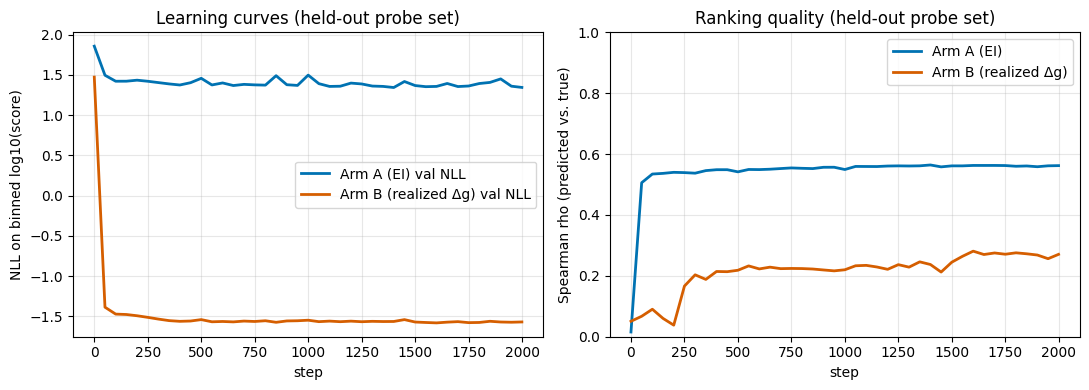

In [5]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history["step"], history["val_loss_ei"], label="Arm A (EI) val NLL", color="#0072B2", linewidth=2)
axes[0].plot(history["step"], history["val_loss_dg"], label="Arm B (realized Δg) val NLL", color="#D55E00", linewidth=2)
axes[0].set_xlabel("step")
axes[0].set_ylabel("NLL on binned log10(score)")
axes[0].set_title("Learning curves (held-out probe set)")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history["step"], history["val_rho_ei"], label="Arm A (EI)", color="#0072B2", linewidth=2)
axes[1].plot(history["step"], history["val_rho_dg"], label="Arm B (realized Δg)", color="#D55E00", linewidth=2)
axes[1].set_xlabel("step")
axes[1].set_ylabel("Spearman rho (predicted vs. true)")
axes[1].set_title("Ranking quality (held-out probe set)")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.tight_layout()
fig.savefig("_demo_plots/vla_readout_ei_probe_learning_curve.png", dpi=150, bbox_inches="tight")
plt.show()


final Arm A (EI):        val NLL 1.3455   Spearman 0.5621
final Arm B (realized):  val NLL -1.5717   Spearman 0.2700
context: Spearman(EI_true, delta_g_true) = 0.0022  (agreement between the analytic target and the realized target themselves)


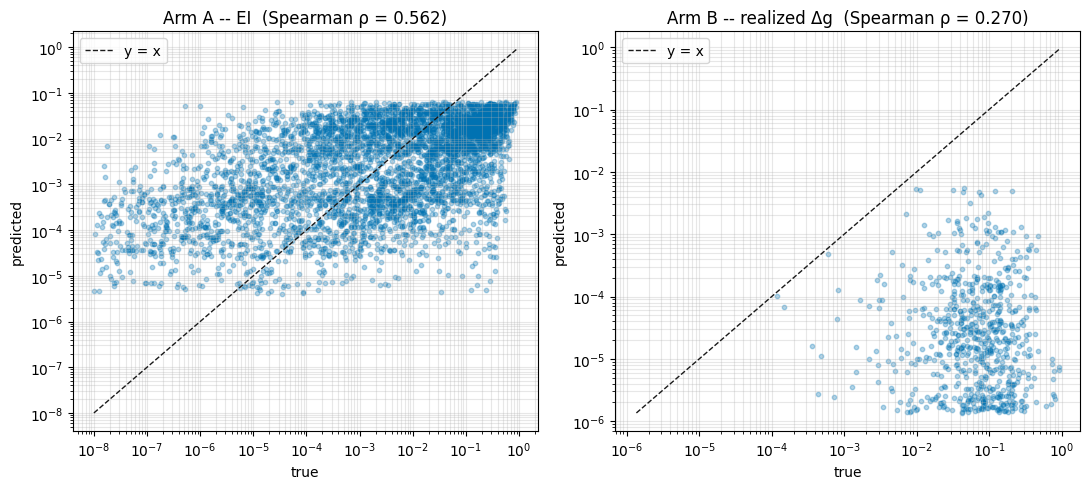

In [6]:

final = evaluate()
print(f"final Arm A (EI):        val NLL {final['loss_ei']:.4f}   Spearman {final['rho_ei']:.4f}")
print(f"final Arm B (realized):  val NLL {final['loss_dg']:.4f}   Spearman {final['rho_dg']:.4f}")

# Context number: how noisy is Arm B's realized single-draw target relative
# to Arm A's clean analytic one, on the SAME candidates? A low value here
# is exactly why Arm B is intrinsically harder, not (only) a readout failure.
rho_ei_vs_dg, _ = spearmanr(final["ei_true"], final["dg_true"])
print(f"context: Spearman(EI_true, delta_g_true) = {rho_ei_vs_dg:.4f}  "
      f"(agreement between the analytic target and the realized target themselves)")

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, true_v, pred_v, rho, title in [
    (axes[0], final["ei_true"], final["ei_pred"], final["rho_ei"], "Arm A -- EI"),
    (axes[1], final["dg_true"], final["dg_pred"], final["rho_dg"], "Arm B -- realized Δg"),
]:
    mask = (true_v > EPS) & (pred_v > EPS)
    ax.scatter(true_v[mask], pred_v[mask], s=10, alpha=0.3, color="#0072B2")
    lims = [min(true_v[mask].min(), pred_v[mask].min()), max(true_v[mask].max(), pred_v[mask].max())]
    ax.plot(lims, lims, color="#1a1a1a", linewidth=1, linestyle="--", label="y = x")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("true")
    ax.set_ylabel("predicted")
    ax.set_title(f"{title}  (Spearman ρ = {rho:.3f})")
    ax.legend()
    ax.grid(alpha=0.3, which="both")

fig.tight_layout()
fig.savefig("_demo_plots/vla_readout_ei_probe_scatter.png", dpi=150, bbox_inches="tight")
plt.show()



## Reading this

**Arm A (EI)** is the sanity check: if `rho_ei` doesn't climb well above 0 with the scatter
tracking `y = x` (loosely — rank matters more than exact value for acquisition purposes), the
readout mechanism itself isn't extracting usable signal from train-token hidden states at all, and
nothing below matters.

**Arm B (realized Δg)** is the actually load-bearing result — this is literally what §4.1's Phase
1 supervised pretraining regresses on. Two distinct things can make `rho_dg` come out lower than
`rho_ei`:
1. **Intrinsic target noise.** A single realized draw is a much noisier training signal than a
   closed-form expectation — that's real and unavoidable, not a readout deficiency. The
   `Spearman(EI_true, delta_g_true)` context number above puts a ceiling on how well ANY model
   could track `delta_g` using EI-like information, since it measures how much the realized draw
   itself disagrees with the analytic expectation on the same candidates.
2. **Readout deficiency.** If `rho_dg` sits meaningfully *below* that ceiling even after training
   converges, the readout isn't extracting all the signal that's actually there.

Distinguishing these two before concluding anything about §3.2 is the point of reporting both
numbers side by side rather than just one aggregate result.

**On the incumbent anchor:** if Arm B lags well behind what the EI-vs-Δg agreement number would
predict, one place to look is whether the incumbent anchor's per-layer embedding is expressive
enough — the same anchor is shared between both arms here, so a deficiency there would show up as
a correlated gap across both.

This is a probe, not a milestone: it doesn't commit `docs/ROADMAP.md` to anything — it's meant to
produce evidence before that decision gets made.
